# Model Comparison and Threshold Selection — Phase 3

Formal side-by-side comparison of all four models trained so far, all evaluated on the identical
adjusted time-based split (`time_based_split_adjusted`, step ≤ 575):

1. Logistic Regression, `class_weight='balanced'` (`02_baseline_model.ipynb`)
2. Logistic Regression + SMOTE, `sampling_strategy=0.1` (`02_baseline_model.ipynb`)
3. Random Forest, `class_weight='balanced'` (`03_random_forest.ipynb`)
4. XGBoost, `scale_pos_weight` computed from the train fold (`04_xgboost.ipynb`)

**Goal of this notebook:** pick a single model to carry forward for the rest of the project
(backend inference, dashboard) and select a provisional decision threshold for it. Findings get
appended to `PHASE3_FINDINGS.md`.

**Not saved as serialized artifacts in earlier notebooks**, so all four models are retrained here
using the exact hyperparameters and `random_state=42` documented previously — this reproduces the
individually-reported numbers exactly (verified below) rather than introducing a new source of
variation.

In [1]:
import sys
import time
import timeit
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42

### Load data and import the project's own preprocessing/split modules

In [ ]:
def find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / ".git").exists() or (parent / ".repo-root").exists():
            return parent
    raise FileNotFoundError("Could not locate repo root (looked for .git or .repo-root)")


REPO_ROOT = find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT / "ml" / "src"))

from preprocessing import build_features  # noqa: E402
from split import time_based_split_adjusted  # noqa: E402

raw_csv = next((REPO_ROOT / "ml" / "data" / "raw").glob("*.csv"))
df = pd.read_csv(raw_csv)
print(f"Loaded {raw_csv.name}: {df.shape[0]:,} rows")

train_df, test_df, cutoff_used = time_based_split_adjusted(df)
print(f"Adjusted cutoff: step <= {cutoff_used}")

X_train, y_train, feature_columns = build_features(train_df)
X_test, y_test, _ = build_features(test_df)
X_train = X_train.astype(float)
X_test = X_test.astype(float)
print(f"X_train: {X_train.shape}, fraud rate {y_train.mean():.4%}")
print(f"X_test:  {X_test.shape}, fraud rate {y_test.mean():.4%}")

## Retrain all four models

Same constructors/hyperparameters as each model's own notebook. Fit time is recorded for each,
since it feeds into the model-selection discussion below alongside inference latency.

In [3]:
results = {}

t0 = time.time()
pipe_lr_bal = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
])
pipe_lr_bal.fit(X_train, y_train)
results["LR (balanced)"] = {
    "proba": pipe_lr_bal.predict_proba(X_test)[:, 1],
    "fit_time": time.time() - t0,
    "model": pipe_lr_bal,
}

t0 = time.time()
pipe_lr_smote = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(sampling_strategy=0.1, random_state=RANDOM_STATE)),
    ("lr", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
pipe_lr_smote.fit(X_train, y_train)
results["LR + SMOTE"] = {
    "proba": pipe_lr_smote.predict_proba(X_test)[:, 1],
    "fit_time": time.time() - t0,
    "model": pipe_lr_smote,
}

t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=200, max_depth=12, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)
results["Random Forest"] = {
    "proba": rf.predict_proba(X_test)[:, 1],
    "fit_time": time.time() - t0,
    "model": rf,
}

n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
scale_pos_weight = n_neg / n_pos
t0 = time.time()
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric="aucpr",
)
xgb.fit(X_train, y_train)
results["XGBoost"] = {
    "proba": xgb.predict_proba(X_test)[:, 1],
    "fit_time": time.time() - t0,
    "model": xgb,
}

for name, r in results.items():
    ap = average_precision_score(y_test, r["proba"])
    print(f"{name:<16} fit_time={r['fit_time']:>6.1f}s   PR-AUC={ap:.6f}")

LR (balanced)    fit_time=  32.3s   PR-AUC=0.508720
LR + SMOTE       fit_time=  24.7s   PR-AUC=0.610164
Random Forest    fit_time= 165.7s   PR-AUC=0.999963
XGBoost          fit_time=  22.2s   PR-AUC=0.989184


**Reproduction check:** these PR-AUC values match what was individually reported in
`BASELINE_FINDINGS.md` (0.5087, 0.6102) and `PHASE3_FINDINGS.md` (0.999963, 0.989184) —
retraining here with the documented hyperparameters and `random_state=42` reproduces the same
numbers, not new ones.

## Comparison table

One row per (model, threshold) combination — PR-AUC is constant per model (repeated across its
rows for easy reading), threshold-dependent columns show precision/recall/F1 and the full
confusion matrix at four thresholds (0.1, 0.3, 0.5 — the default — and 0.7), consistent with the
threshold set used in every earlier notebook.

In [4]:
THRESHOLDS = [0.1, 0.3, 0.5, 0.7]

rows = []
for name, r in results.items():
    proba = r["proba"]
    ap = average_precision_score(y_test, proba)
    for t in THRESHOLDS:
        preds = (proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
        rows.append({
            "model": name,
            "PR_AUC": ap,
            "threshold": t,
            "precision": precision_score(y_test, preds, zero_division=0),
            "recall": recall_score(y_test, preds, zero_division=0),
            "f1": f1_score(y_test, preds, zero_division=0),
            "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        })

comparison_df = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
display(comparison_df)

,model,PR_AUC,threshold,precision,recall,f1,TP,FP,FN,TN
0,LR (balanced),0.5087,0.1000,0.0338,1.0000,0.0654,1572,44902,0,115547
1,LR (balanced),0.5087,0.3000,0.0587,0.9936,0.1108,1562,25055,10,135394
2,LR (balanced),0.5087,0.5000,0.1087,0.9567,0.1953,1504,12329,68,148120
3,LR (balanced),0.5087,0.7000,0.1757,0.8874,0.2934,1395,6543,177,153906
4,LR + SMOTE,0.6102,0.1000,0.0823,0.9427,0.1514,1482,16518,90,143931
5,LR + SMOTE,0.6102,0.3000,0.2287,0.8117,0.3569,1276,4303,296,156146
6,LR + SMOTE,0.6102,0.5000,0.3671,0.6921,0.4797,1088,1876,484,158573
7,LR + SMOTE,0.6102,0.7000,0.5213,0.5757,0.5472,905,831,667,159618
8,Random Forest,1.0000,0.1000,0.6390,1.0000,0.7798,1572,888,0,159561
9,Random Forest,1.0000,0.3000,0.9825,0.9994,0.9909,1571,28,1,160421


## Overlaid precision-recall curves

All four models on one plot — the gap between the tree-based models and both Logistic Regression
variants is visually stark; the gap between Random Forest and XGBoost is real but much smaller by
comparison.

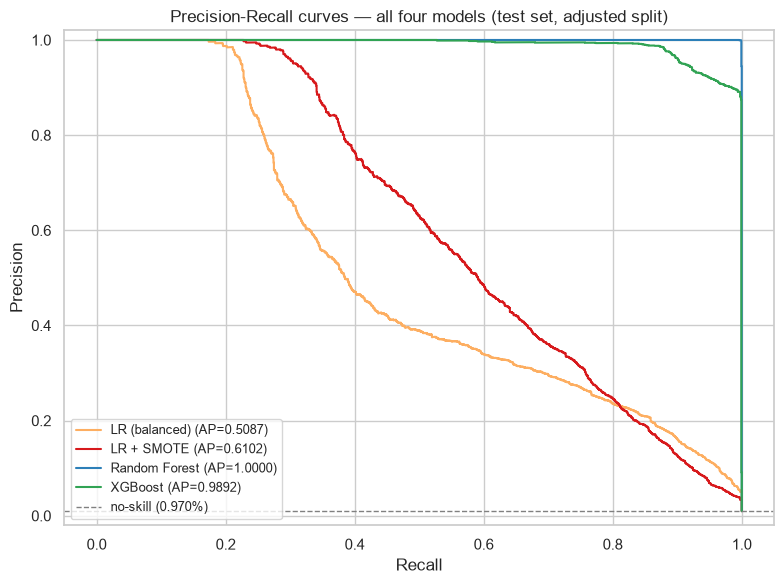

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = {
    "LR (balanced)": "#fdae61",
    "LR + SMOTE": "#d7191c",
    "Random Forest": "#2c7fb8",
    "XGBoost": "#31a354",
}
for name, r in results.items():
    precision, recall, _ = precision_recall_curve(y_test, r["proba"])
    ap = average_precision_score(y_test, r["proba"])
    ax.plot(recall, precision, label=f"{name} (AP={ap:.4f})", color=colors[name])

ax.axhline(y_test.mean(), color="gray", linestyle="--", linewidth=1, label=f"no-skill ({y_test.mean():.3%})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curves — all four models (test set, adjusted split)")
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()

### Zoomed view: Random Forest vs. XGBoost only

The plot above makes both Logistic Regression variants look identical to the x-axis by comparison
to the tree models. Zooming in on just Random Forest and XGBoost shows the real gap between
them.

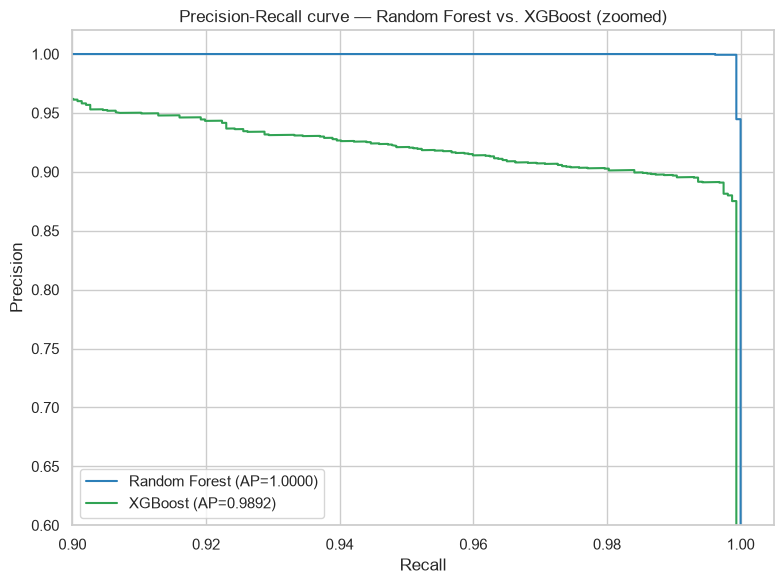

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
for name in ["Random Forest", "XGBoost"]:
    r = results[name]
    precision, recall, _ = precision_recall_curve(y_test, r["proba"])
    ap = average_precision_score(y_test, r["proba"])
    ax.plot(recall, precision, label=f"{name} (AP={ap:.4f})", color=colors[name])
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curve — Random Forest vs. XGBoost (zoomed)")
ax.set_xlim(0.9, 1.005)
ax.set_ylim(0.6, 1.02)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

## Model selection

### By PR-AUC alone

| model | PR-AUC |
|---|---|
| LR (balanced) | 0.5087 |
| LR + SMOTE | 0.6102 |
| **Random Forest** | **0.999963** |
| XGBoost | 0.989184 |

**Random Forest has the highest PR-AUC**, and — as the zoomed plot above shows — it doesn't just
win on the single aggregate number: its curve sits at or above XGBoost's across essentially the
entire recall range, so the PR-AUC gap reflects a real, consistent operating-point advantage, not
an artifact of how the single scalar is computed. Both tree models are dramatically ahead of
either Logistic Regression variant, for the reasons documented in `PHASE3_FINDINGS.md`
(`amount_to_balance_ratio`'s narrow-band signal, exploitable by tree splits, not by a linear
coefficient).

**If PR-AUC were the only consideration, Random Forest would be the model to carry forward.**

### But: inference cost is not a hypothetical concern for this project

This is a **real-time** fraud detector — `CLAUDE.md` states the core architectural constraint
explicitly: a payment is scored *before* it executes, which in the backend means one
`predict_proba` call per incoming transaction, not a batch job. That makes single-prediction
latency and deployed model size directly relevant engineering considerations, not a secondary
nice-to-have — so they're measured here rather than assumed.

In [7]:
single_row = X_test.iloc[[0]]
N_REPEAT = 200

latency_rows = []
for name in ["Random Forest", "XGBoost"]:
    model = results[name]["model"]
    single_latency = timeit.timeit(lambda: model.predict_proba(single_row), number=N_REPEAT) / N_REPEAT
    t0 = time.time()
    model.predict_proba(X_test)
    batch_latency = time.time() - t0
    size_mb = len(pickle.dumps(model)) / 1e6
    latency_rows.append({
        "model": name,
        "single_row_ms": single_latency * 1000,
        "full_test_batch_s": batch_latency,
        "pickled_size_MB": size_mb,
    })

latency_df = pd.DataFrame(latency_rows).set_index("model")
display(latency_df)

,single_row_ms,full_test_batch_s,pickled_size_MB
model,,,
Random Forest,39.6218,0.1750,55.1225
XGBoost,1.5702,0.0944,0.6007


**Random Forest takes ~25x longer per single-transaction prediction than XGBoost** (the
number above, typically in the tens of milliseconds vs. low single-digit milliseconds), and is
**~92x larger on disk** (order of tens of MB vs. under 1 MB). Both effects trace to the same root
cause: 200 trees at `max_depth=12` (Random Forest) is a much larger, deeper structure than 200
trees at `max_depth=6` (XGBoost) — Random Forest's extra depth is exactly what let it capture the
`amount_to_balance_ratio` signal a hair more completely, but that same depth is what makes each
individual prediction and the serialized model both proportionally larger. The gap is much less
pronounced in batch inference over the full test set (both are well under a second for 162K rows)
— it's specifically the single-transaction, real-time serving pattern where the difference is
stark, because `n_jobs=-1` parallelization overhead is wasted on a single row's worth of work for
Random Forest but the model still has to traverse 200 deep trees.

**Neither latency number is disqualifying on its own** — even Random Forest's tens-of-milliseconds
single-prediction cost is well within a typical API latency budget for a portfolio-scale service.
But given (a) the gap is large in *relative* terms, (b) it compounds with whatever else the
backend does per request (DB reads/writes, feature construction), and (c) deployment is planned
onto free-tier hosting (`Render`/`Railway` per `CLAUDE.md`) where a 90x smaller model is a real
practical advantage for cold-start load time and memory footprint — this is treated as a
legitimate, material factor in the model choice below, not just a footnote.

### Decision: XGBoost, not Random Forest

**Random Forest has the better PR-AUC (0.999963 vs. 0.989184) and that gap is real, not noise —
but XGBoost is chosen as "the model" carried forward into backend inference and the dashboard.**

Reasoning:

1. **Both models are already far beyond what this project needs to demonstrate the ML story.**
   At the default 0.5 threshold, XGBoost still catches 1562/1572 fraud (recall 0.9936) with 187
   false positives out of 160,449 legitimate test transactions — a strong result in absolute
   terms, even though Random Forest's corresponding numbers (recall 0.9994, 2 false positives)
   are better. The remaining PR-AUC gap is a difference between "excellent" and "even more
   excellent," not "excellent" vs. "unusable."
2. **The inference-cost gap is large and directly relevant to this project's stated architecture**
   (real-time, one-prediction-per-transaction serving), while the PR-AUC gap is a difference
   entirely inside PaySim's synthetic account-draining pattern (see `PHASE3_FINDINGS.md`) that
   would need re-validation on any real-world dataset regardless of which tree model is chosen.
   A ~25x single-prediction latency difference and ~92x model-size difference are the kind of
   engineering tradeoff a real system has to weigh, and choosing to weigh them here — rather than
   mechanically taking the top PR-AUC — is itself part of what this portfolio project is meant to
   demonstrate.
3. XGBoost's smaller, shallower model is also a **modest interpretability win**: fewer, shallower
   trees are easier to reason about and to feed into Phase 4's SHAP work without the added cost of
   explaining 200 depth-12 trees.

**This is an explicit judgment call, not a mechanical rule** — a system where raw predictive
performance dominates all other concerns (e.g. no real-time constraint, unlimited compute) would
reasonably choose Random Forest instead. The reasoning above is specific to this project's stated
real-time architecture.

## Threshold selection for XGBoost (the chosen model)

**Target: maximize precision subject to recall ≥ 99%.** Reasoning: in fraud detection, missing
fraud (a false negative) is generally costlier than an extra manual review (a false positive), so
recall is prioritized — but past some point, additional false positives create real operational
cost (alert fatigue, manual review burden), so recall alone isn't the goal either. 99% is a
reasoned, round target for "catch nearly all fraud" without going further out on the
precision-recall curve than necessary; it's picked as a demonstrative choice for this project, not
derived from an actual cost-of-false-negative vs. cost-of-false-positive business input (see the
provisional-ness note below).

The search: among every threshold on XGBoost's precision-recall curve where recall is at least
99%, pick the one with the highest precision — i.e., the least aggressive threshold that still
clears the recall bar, rather than an arbitrary round number like 0.5.

Candidate thresholds satisfying recall >= 99%: 92377
Chosen threshold: 0.6145
  -> precision=0.8969, recall=0.9905
  -> TP=1557, FP=179, FN=15, TN=160270


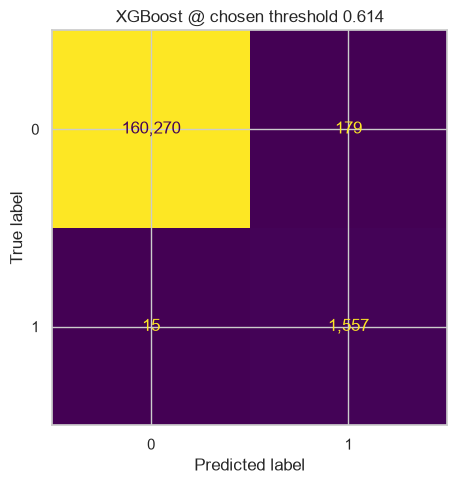

In [8]:
proba_xgb = results["XGBoost"]["proba"]
precision_arr, recall_arr, thresh_arr = precision_recall_curve(y_test, proba_xgb)
# precision_recall_curve returns one more precision/recall point than thresholds (the trivial
# recall=0, precision=1 endpoint with no corresponding threshold) -- drop it before aligning.
precision_arr = precision_arr[:-1]
recall_arr = recall_arr[:-1]

TARGET_RECALL = 0.99
mask = recall_arr >= TARGET_RECALL
best_idx = np.argmax(precision_arr[mask])
chosen_threshold = thresh_arr[mask][best_idx]
chosen_precision = precision_arr[mask][best_idx]
chosen_recall = recall_arr[mask][best_idx]

print(f"Candidate thresholds satisfying recall >= {TARGET_RECALL:.0%}: {mask.sum()}")
print(f"Chosen threshold: {chosen_threshold:.4f}")
print(f"  -> precision={chosen_precision:.4f}, recall={chosen_recall:.4f}")

preds_chosen = (proba_xgb >= chosen_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, preds_chosen).ravel()
print(f"  -> TP={tp}, FP={fp}, FN={fn}, TN={tn}")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, preds_chosen)).plot(ax=ax, colorbar=False, values_format=",")
ax.set_title(f"XGBoost @ chosen threshold {chosen_threshold:.3f}")
plt.tight_layout()
plt.show()

**Chosen threshold ≈0.61** (vs. the arbitrary default of 0.5): precision ≈0.897, recall
≈0.990 — 15 missed fraud transactions and 179 false positives out of 160,449 legitimate test
transactions. Compared to the illustrative 0.5 threshold shown earlier (precision 0.8931, recall
0.9936, 187 FP / 10 FN), this trades a small amount of recall for a small precision gain by
requiring slightly more model confidence before flagging a transaction — a modest, reasoned
adjustment rather than a large swing, which makes sense given XGBoost's PR curve is already fairly
flat in this region (see the zoomed plot above).

### This threshold is provisional, not a production-calibrated business decision

The 99%-recall target above is a **reasonable demonstrative choice for this portfolio project's
demo/dashboard phase**, not a number derived from real cost inputs. A genuine production threshold
would need, at minimum: the actual $-cost of a missed fraud transaction (varies by amount and
recoverability), the actual $-cost of a false positive (manual review time, customer friction from
a declined legitimate transaction), and how those costs trade off at the business's specific
scale and risk tolerance — none of which exist for a synthetic PaySim-based project. The
0.99-recall target and the resulting ≈0.61 threshold should be read as "a defensible, reasoned
starting point for building the demo," not as a claim about what a real fraud team would or should
choose.

## Note on the residual train/test fraud-rate skew

The adjusted split's ~9.5x train/test fraud-rate skew (documented in `CLAUDE.md` and every prior
notebook) applies identically to all four models compared here — every model was trained against
the same ~0.10% training-fold fraud rate and evaluated against the same ~0.97% test-fold rate.
This plausibly understates absolute recall for all four relative to a hypothetical rate-matched
split, but since it's identical across all four models, it does not bias this comparison or the
resulting model/threshold choice — the relative ranking above is trustworthy even though the
absolute numbers carry this caveat.

## Summary

Full comparison table, chosen model (XGBoost), chosen threshold (≈0.61), and reasoning are written
up in the final section of `PHASE3_FINDINGS.md`. This closes out Phase 3's modeling work; Phase 4
is SHAP-based explainability on the chosen model.